# RNA sequencing

<a href="?print-pdf">print view</a>  
<a href="ClusteringAndDimensionalityReduction.ipynb" download>notebook</a>

# Final Project/Exam

- **Dates: December 2 and 4, 2025 (During class hours)**
- **Duration: Approximately 10 mins**
- **Topics: Homeworks**

# What is RNA

- RNA: Ribonucleic acid
- Single stranded molecule
- Assembled as a chain of nucleotides
- Each nucleotide contains: ribose sugar, phosphate group, base (**A**denine, **C**ytosine, **G**uanine, **U**racil)
  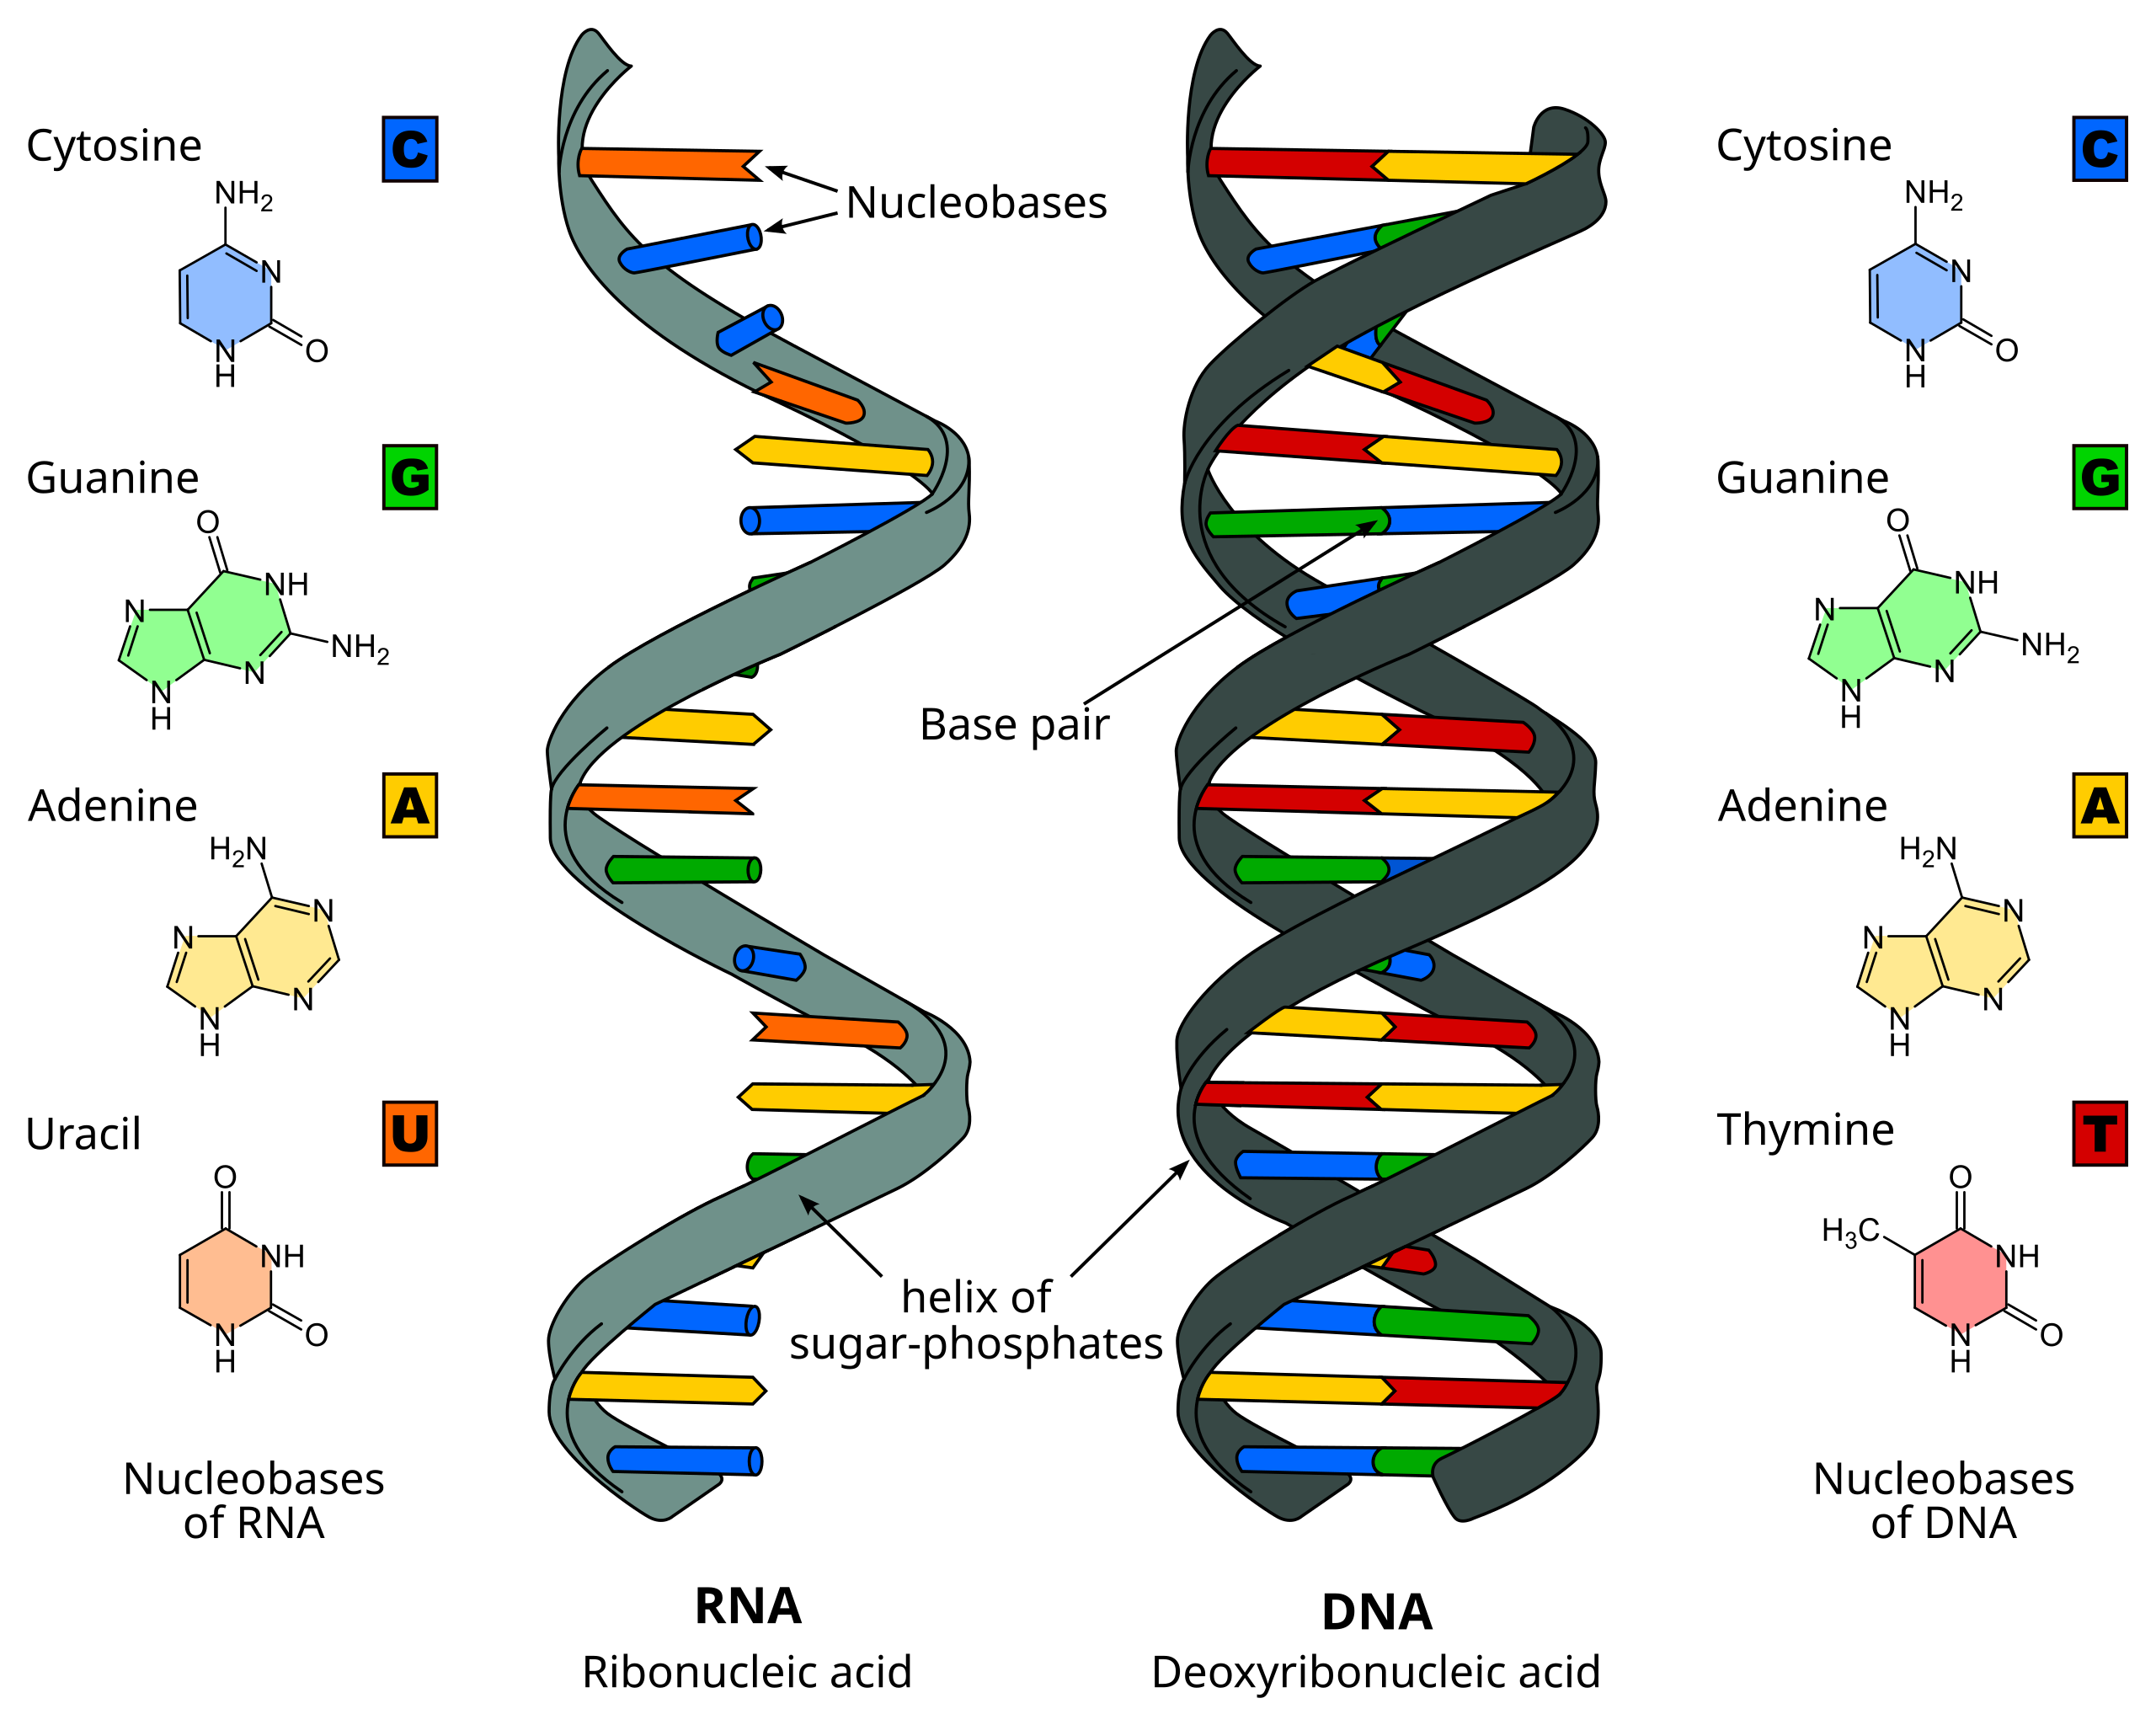

# Library Preparation

- **RNA is harvested from the source material. This could be cells, tissue, etc.**
- **RNA is fragmented into smaller pieces.**
- **RNA fragments are reverse-transcribed to produce complementary DNA (cDNA) fragments, whose ends contain adapter sequences.**


# Amplification and Sequencing by Synthesis

- **cDNA library is loaded into a flow cell, where it is anchored by the adapters.**
- **cDNA is amplified so that identical sequences are located in the same position on the flow cell**

- **New DNA is synthesized with fluorescently labeled nucleotides−A, T, C, and G have a unique fluorescence signal.**
- **The sequencing machine reads the fluorescence signal for each cluster at each cycle of synthesis.**
  

# Data processing

- **The sequence of fluorescence signals at each cluster is converted into an RNA sequence.The full sequence for each fragment is called a “read.”**
- **Sequencing adapters are trimmed, the reads are filtered according to a set quality thresholds**
- **The reads are mapped to a reference genome to determine which gene a fragment belongs to. (Alignment)**
- **Gene expression is quantified by counting the number of reads per gene.**

# FASTA

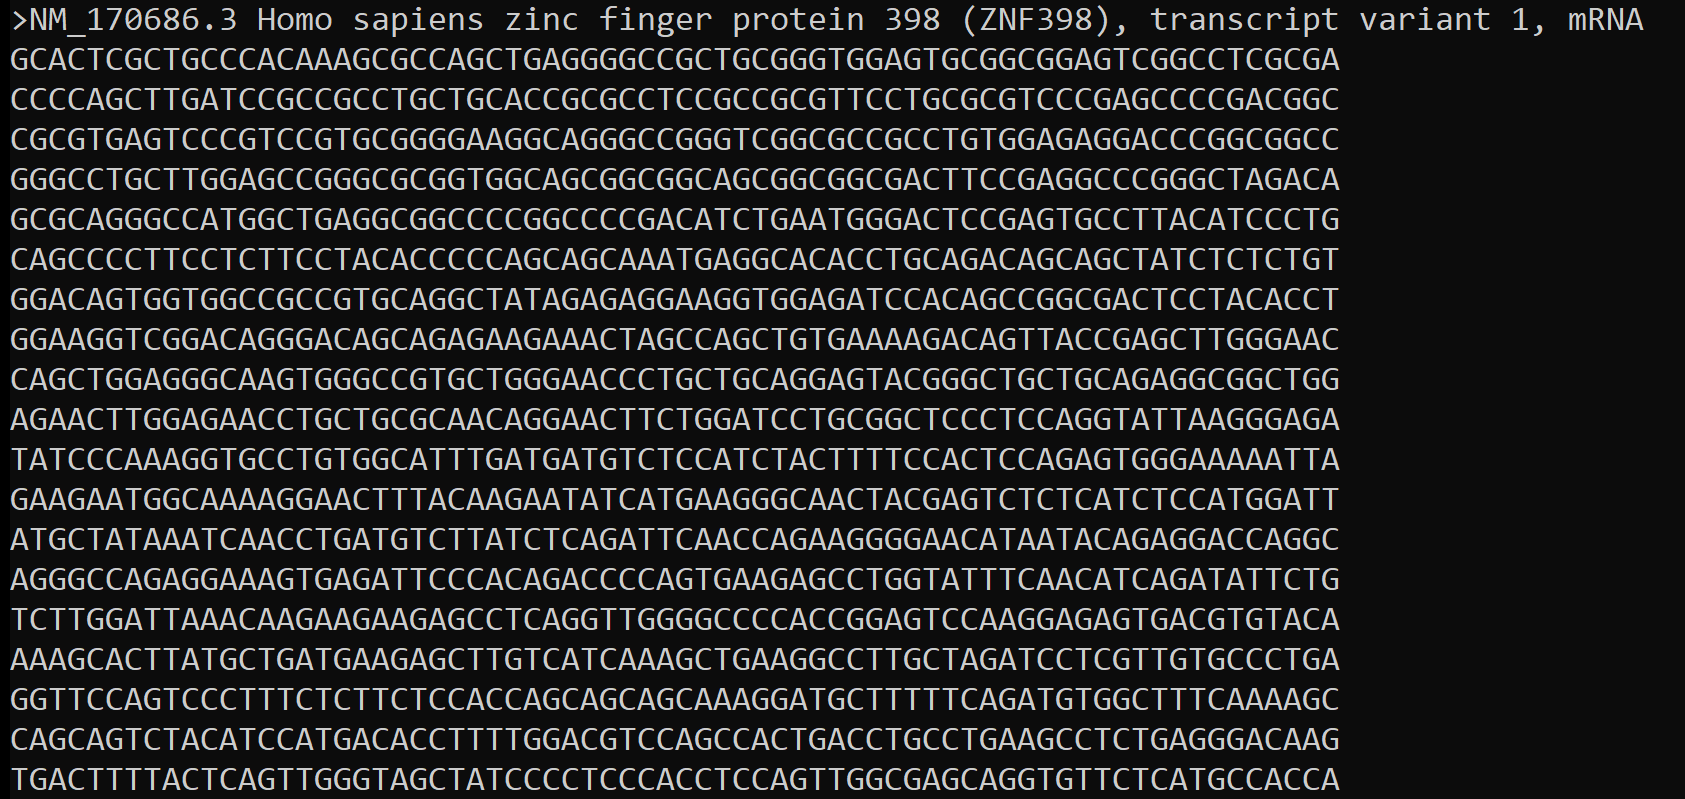

# FASTA

- **Contains only the sequence information (nucleotide or amino acids)**
- **Commonly used for reference genomes, gene libraries, or protein sequences**
- **Use Biopython library to read fasta files**

In [ ]:
from Bio import SeqIO

fasta_file = "znf398.fasta"

# Iterate over each record in the FASTA file
for record in SeqIO.parse(fasta_file, "fasta"):
    print("ID:", record.id)
    print("Sequence:", str(record.seq))
    print()

# FASTQ

- **Used for raw sequencing data produced by next-generation sequencing platforms**
- **Contains the sequence information and base-by-base quality scores for each read**
- **Each record consists of four lines:**
    - a header (starting with "@"), 
    - the sequence, 
    - a separator line ("+"), 
    - and a quality score line


# FASTQ
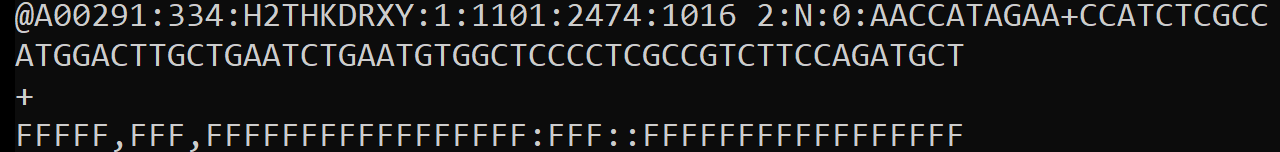

# Phread quality score (Q)

- **Indicated (per base) by the quality score line**
- **Phred Quality Score (Q): Represents the probability that a base was incorrectly identified by the sequencer**
- **Q = -10$\mathbf{\log_{10}}$(P)**

# QUIZ

## Two bases have a Q score of 20 and 50 respectively. Which one has better quality?

# Phread+33 encoding
- **Phred+33 encoding: encodes quality scores by adding 33 to each Phred quality score and converting to an ASCII character**
- **For example**,
- **Phred score of 35 is encoded as the ASCII character “D” (68 = 35+33)**
- **F = ASCII 70 → Q = 37 (very high quality, very low error probability)**
- **: = ASCII 58 → Q = 25 (medium quality)**
- **, = ASCII 44 → Q = 11 (low quality)**
- **! = ASCII 30 → Q = 0 (yikes!!)**

# FASTQC

- **Not a sequence file**
- **Report generated by the fastqc command/software after it has analyzes the fastq file**
- **Contains visual summaries, tables, and graphs for QC metrics (read quality, GC content, adapter contamination, etc.)**
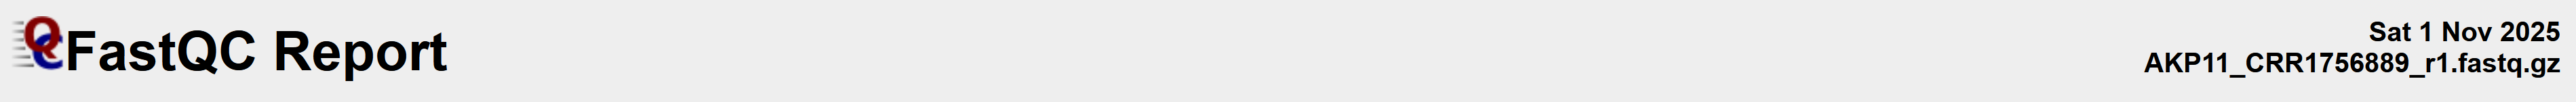

# FASTQC
- **Basic Statistics** - Basic fastq file properties (number of reads, length, encoding).
- **Per base sequence quality** - Quality score for each base position across all reads
- **Per tile sequence quality** - Quality across different areas (tiles) of the sequencing flow cell
- **Per sequence quality scores** - Distribution of overall quality for all reads
- **Per base sequence content** - Nucleotide proportions (A/T/G/C) at each position in the read. [A fail often means strong bias at some positions. Could be due to primer/adaptor contamination, PCR artifacts, or poor library prep.]
- **Per sequence GC content** - Distribution of GC percentages for all reads. [A pass if the %GC is in the expected range for the target organism/library.]
- **Per base N content** - Proportion of ambiguous (‘N’) base calls per position. [A pass means few or no positions with high frequency of ‘N’s.]
- **Sequence Length Distribution** - Distribution of read lengths
- **Percentage of duplicated reads detected** - High duplication can happen, for example, when there is no low-input RNA or there are highly expressed genes. However, if duplication is moderate to high, it could suggest PCR bias, over-amplification, or technical repetition.
- **Overrepresented sequences** - Percent of sequences representing the same motif/sequence far more than expected by chance. Captures possible contamination, strong PCR artifacts.
- **Adapter Content** - Presence of known adapter sequences used in library prep. [A pass means the sequences are clean of adapter context]

# FASTQC
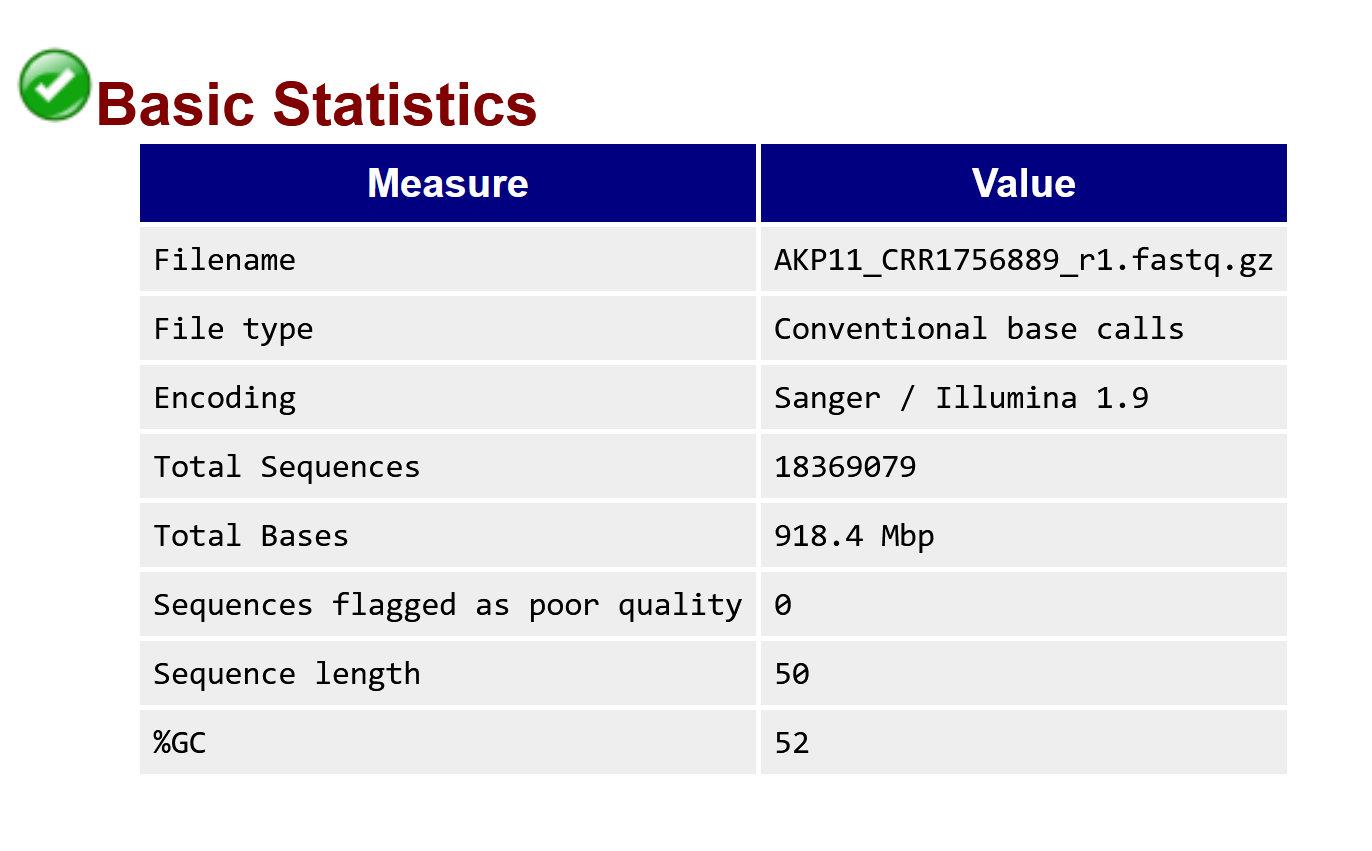

# FASTQC
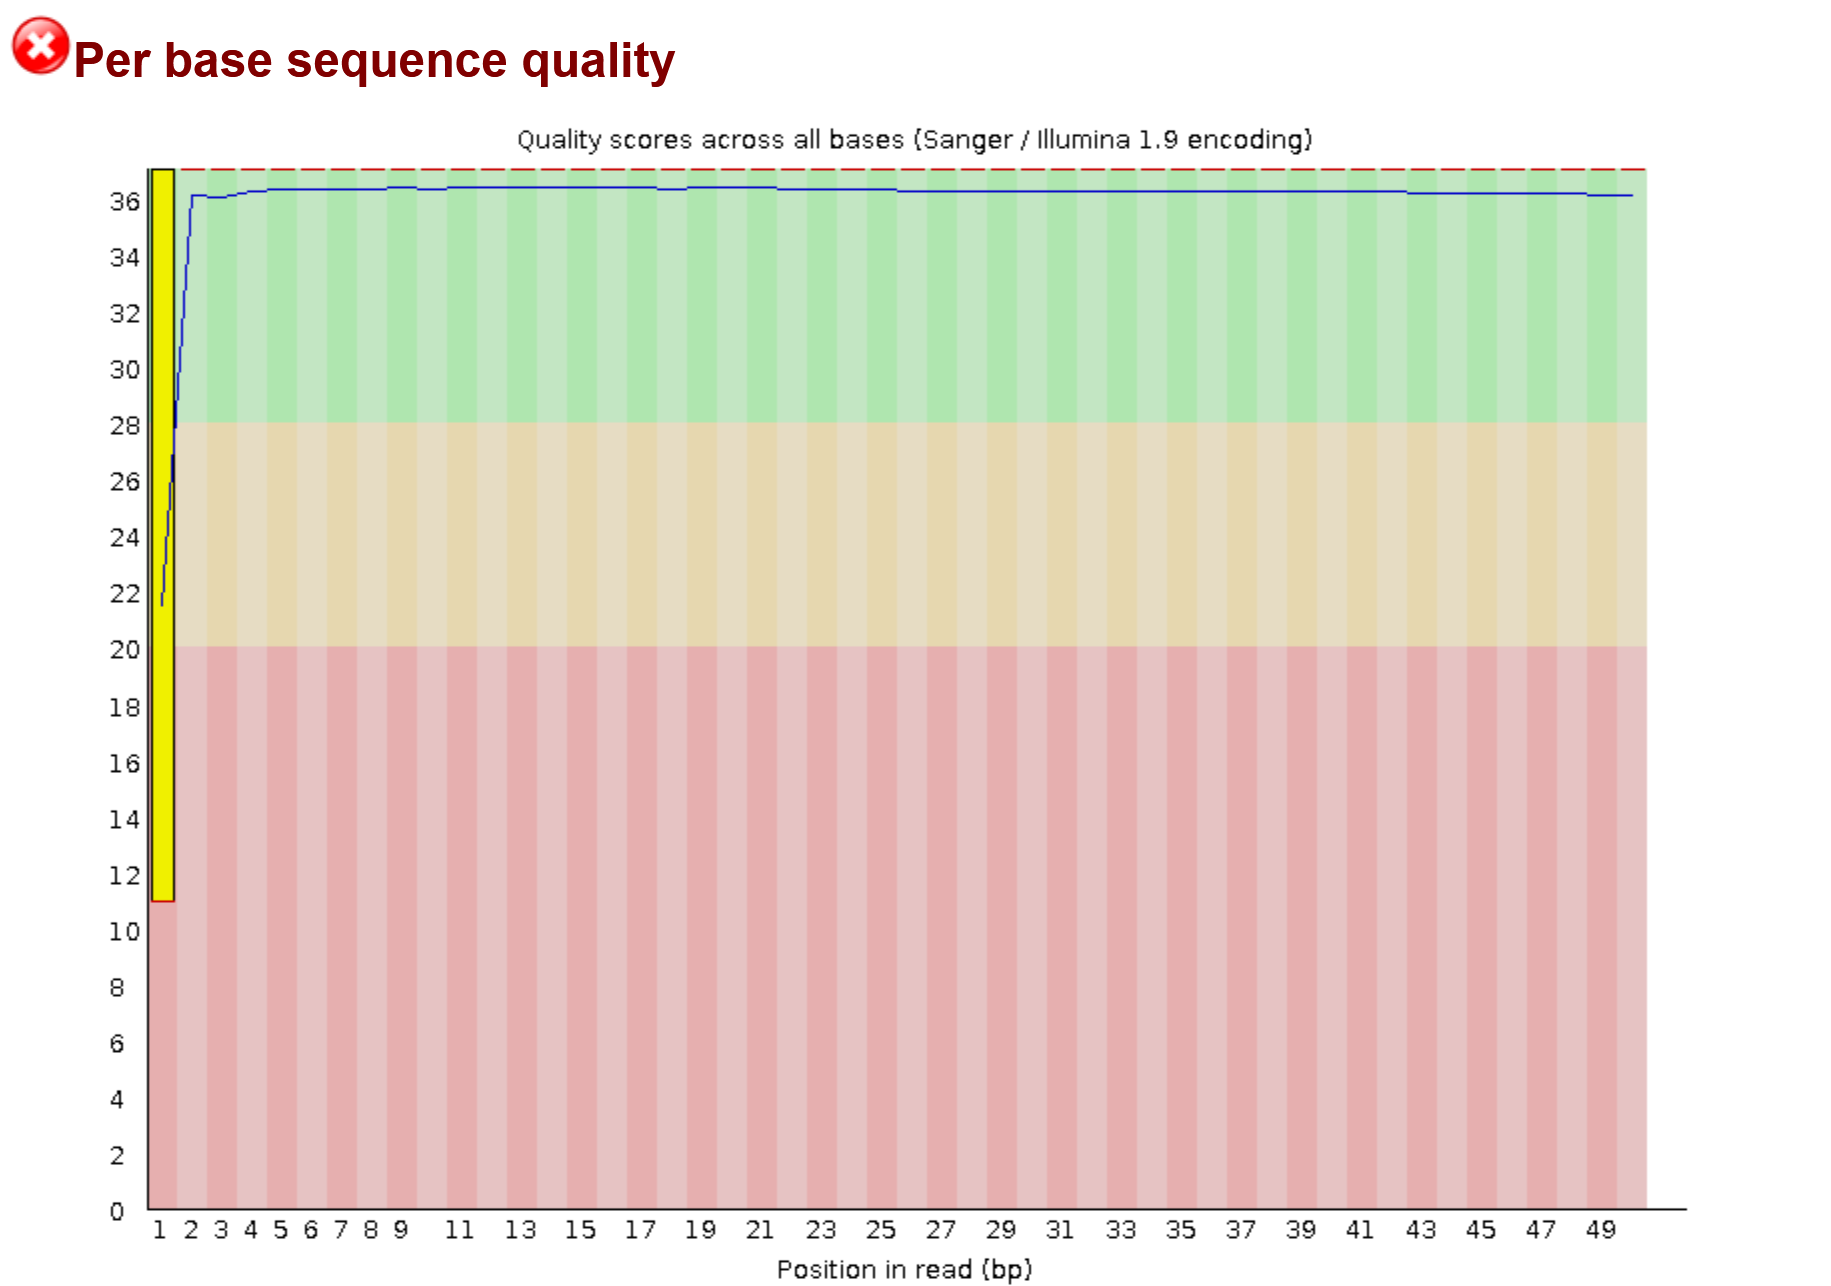

# QUIZ

- Download the fastq file from here: 'https://download.cncb.ac.cn/gsa4/CRA024763/CRR1756889/CRR1756889_r1.fastq.gz'
- Perform fastqc and look at the report.
- Command: **fastqc -o output-directory fastq-file**